# Vector Fields - Sinking Vortex
## Sink + Vortex

### 1. But First, a little visualization

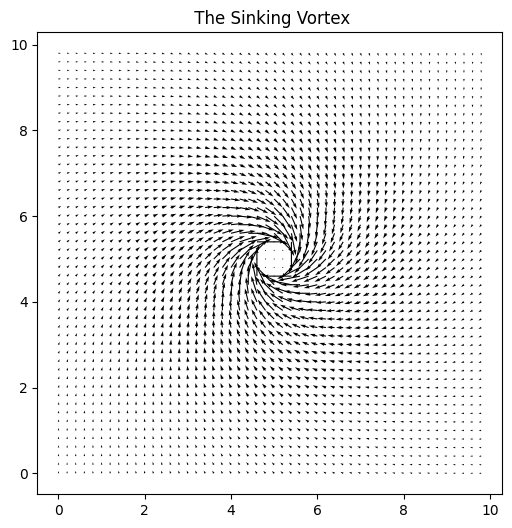

In [1]:
## 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# 2. Define constants
x_start = y_start = 0
x_end = y_end = 10
quiver_step_size = 0.2
x_source = y_source = 5

# 3. Declare Functions

def sinking_vortex(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source

    # Calculate the distance r from the center
    r = np.sqrt(x_centre**2 + y_centre**2)
    r[r<0.5] = 100

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / r 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / r
    v = -v_theta * x_centre / r

    # Add (-) the sink vector components
    u -=  x_centre / r**2
    v -=  y_centre / r**2

    return u, v

# Function to plot sink and vortex
def plot_extra_features(x, y, u, v, x_source, y_source):


    # Create circle
    circle = plt.Circle((x_source, y_source), 2, color='red', fill=False)

    # Add the circle to the plot
    plt.gca().add_patch(circle)

    # Set aspect ratio to be equal, so the circle looks circular
    plt.gca().set_aspect('equal')

    # Add source point
    plt.scatter(x_source, y_source, color='red', marker='x', linewidths=2.5)

    # Set title and show plot
    plt.title("sink at (5, 5 and radius of constant magnitude)")
    plt.show()
    
# 4. Initialize
x = np.arange(x_start, x_end, quiver_step_size)
y = np.arange(y_start, y_end, quiver_step_size)
X, Y = np.meshgrid(x, y)

# 5. Main 

u, v = sinking_vortex(X, Y, x_source, y_source)

# 6. Plot Outcome

plt.figure(figsize=(6, 6))
plt.quiver(x, y, u, v)
plt.title(' The Sinking Vortex')
#plot_extra_features(x, y, u, v, x_source, y_source)
plt.show()



## Direction Follower to Centre

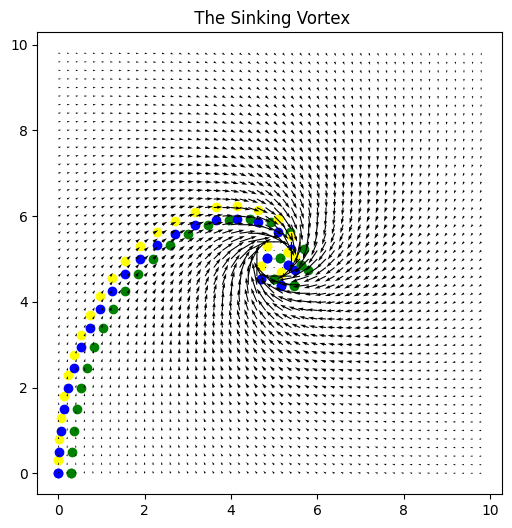

In [2]:
## 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# 2. Define constants
x_start = y_start = 0
x_end = y_end = 10
quiver_step_size = 0.2
x_source = y_source = 5

robot_1_start = [0,0]
robot_2_offset = [0,0.3]
robot_3_offset = [0.3,0]

robot_step_size = 0.5

# 3. Declare Functions

def sinking_vortex(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source

    # Calculate the distance r from the center
    r = np.sqrt(x_centre**2 + y_centre**2)
    r[r<0.5] = 100

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / r 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / r
    v = -v_theta * x_centre / r

    # Add (-) the sink vector components
    u -=  x_centre / r**2
    v -=  y_centre / r**2

    return u, v

def robot_readings(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source
    
    # Calculate the distance r from the center
    dist = np.sqrt((x-x_source)**2 + (y-y_source)**2)
    

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / dist 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / dist
    v = -v_theta * x_centre / dist

    # Add (-) the sink vector components
    u -=  x_centre / dist**2
    v -=  y_centre / dist**2
                   
    return u, v

def composite_vector(u,v):
    
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v2,u2)
    
    return mag, angle

def plot_robot_position(pos1,pos2,pos3):

    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    
    
def update_robot_position(pos1,pos2,pos3, angle, step_size):
    
    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3
# 4. Initialize

# Initialize The Sinking Vortex Field
x = np.arange(x_start, x_end, quiver_step_size)
y = np.arange(y_start, y_end, quiver_step_size)
X, Y = np.meshgrid(x, y)
u, v = sinking_vortex(X, Y, x_source, y_source)

# Initialize the Robot's positions
pos1=robot_1_start
pos2=[(robot_1_start[0] + robot_2_offset[0]),(robot_1_start[1] + robot_2_offset[1])]
pos3=[(robot_1_start[0] + robot_3_offset[0]),(robot_1_start[1] + robot_3_offset[1])]

# Initialize output Plot
plt.figure(figsize=(6, 6))
plot_robot_position(pos1,pos2,pos3)

# 5. Main

for _ in range(1,30):
    # Check Break Criteria

    # Find u,v, angle and magnitude at each Robot

    [u1, v1] = robot_readings(pos1[0],pos1[1], x_source,y_source)
    [u2, v2] = robot_readings(pos2[0],pos2[1], x_source,y_source)
    [u3, v3] = robot_readings(pos3[0],pos3[1], x_source,y_source)

    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)

    # Plot Robot Position
    plot_robot_position(pos1,pos2,pos3)

    # Update Robot Position
    angle = (angle1 + angle2 + angle3)/3
    [pos1, pos2, pos3] = update_robot_position(pos1,pos2,pos3,angle, robot_step_size)


# 6. Plot Outcome


plt.quiver(x, y, u, v)
plt.title(' The Sinking Vortex')
#plot_extra_features(x, y, u, v, x_source, y_source)
plt.show()


In [3]:
angle

-1.8645786826399986

## Magnitude Technique

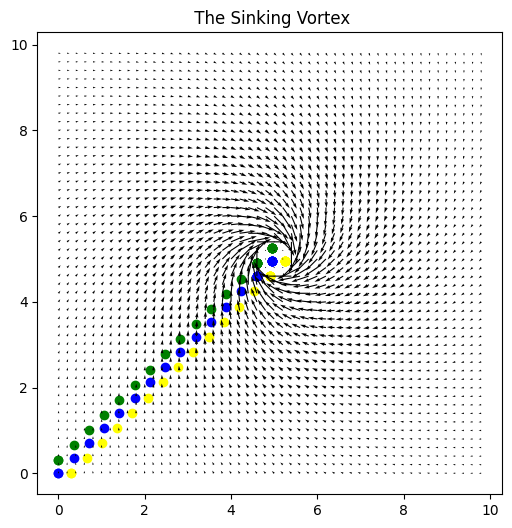

In [4]:
## 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# 2. Define constants
x_start = y_start = 0
x_end = y_end = 10
quiver_step_size = 0.2
x_source = y_source = 5

robot_1_start = [0,0]
robot_2_offset = [0.3,0]
robot_3_offset = [0,0.3]

robot_step_size = 0.5

# 3. Declare Functions

def sinking_vortex(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source

    # Calculate the distance r from the center
    r = np.sqrt(x_centre**2 + y_centre**2)
    r[r<0.5] = 100

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / r 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / r
    v = -v_theta * x_centre / r

    # Add (-) the sink vector components
    u -=  x_centre / r**2
    v -=  y_centre / r**2

    return u, v

def robot_readings(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source
    
    # Calculate the distance r from the center
    dist = np.sqrt((x-x_source)**2 + (y-y_source)**2)
    

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / dist 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / dist
    v = -v_theta * x_centre / dist

    # Add (-) the sink vector components
    u -=  x_centre / dist**2
    v -=  y_centre / dist**2
                   
    return u, v

def composite_vector(u,v):
    
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v2,u2)
    
    return mag, angle

def plot_robot_position(pos1,pos2,pos3):

    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    
    
def update_robot_position(pos1,pos2,pos3, angle, step_size):
    
    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3
# 4. Initialize

# Initialize The Sinking Vortex Field
x = np.arange(x_start, x_end, quiver_step_size)
y = np.arange(y_start, y_end, quiver_step_size)
X, Y = np.meshgrid(x, y)
u, v = sinking_vortex(X, Y, x_source, y_source)

# Initialize the Robot's positions
pos1=robot_1_start
pos2=[(robot_1_start[0] + robot_2_offset[0]),(robot_1_start[1] + robot_2_offset[1])]
pos3=[(robot_1_start[0] + robot_3_offset[0]),(robot_1_start[1] + robot_3_offset[1])]

# Initialize output Plot
plt.figure(figsize=(6, 6))
plot_robot_position(pos1,pos2,pos3)

# 5. Main

for _ in range(1,30):
    # Check Break Criteria

    # Find u,v, angle and magnitude at each Robot

    [u1, v1] = robot_readings(pos1[0],pos1[1], x_source,y_source)
    [u2, v2] = robot_readings(pos2[0],pos2[1], x_source,y_source)
    [u3, v3] = robot_readings(pos3[0],pos3[1], x_source,y_source)

    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)

    # Plot Robot Position
    plot_robot_position(pos1,pos2,pos3)

    # Update Robot Position
    slope_x = (mag2 - mag1) / robot_2_offset[0] 
    slope_y = (mag3 - mag1) / robot_3_offset[1] 
    angle = np.arctan2(slope_y,slope_x)
    
    [pos1, pos2, pos3] = update_robot_position(pos1,pos2,pos3,angle, robot_step_size)


# 6. Plot Outcome


plt.quiver(x, y, u, v)
plt.title(' The Sinking Vortex')
#plot_extra_features(x, y, u, v, x_source, y_source)
plt.show()


## How about a circle

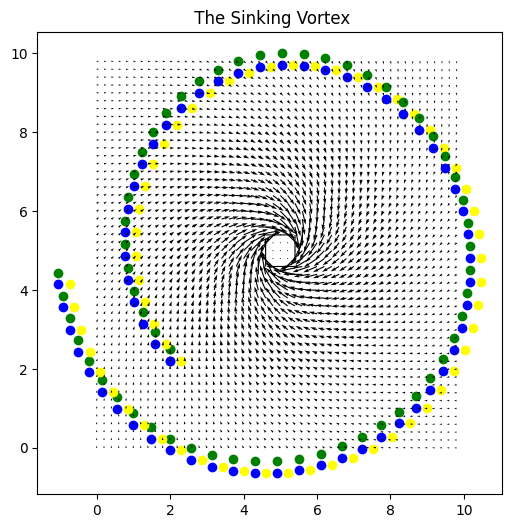

In [5]:
## 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# 2. Define constants
x_start = y_start = 0
x_end = y_end = 10
quiver_step_size = 0.2
x_source = y_source = 5

robot_1_start = [2,2.2]
robot_2_offset = [0.3,0]
robot_3_offset = [0,0.3]

robot_step_size = 0.6

# 3. Declare Functions

def sinking_vortex(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source

    # Calculate the distance r from the center
    r = np.sqrt(x_centre**2 + y_centre**2)
    r[r<0.5] = 100

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / r 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / r
    v = -v_theta * x_centre / r

    # Add (-) the sink vector components
    u -=  x_centre / r**2
    v -=  y_centre / r**2

    return u, v

def robot_readings(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source
    
    # Calculate the distance r from the center
    dist = np.sqrt((x-x_source)**2 + (y-y_source)**2)
    

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / dist 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / dist
    v = -v_theta * x_centre / dist

    # Add (-) the sink vector components
    u -=  x_centre / dist**2
    v -=  y_centre / dist**2
                   
    return u, v

def composite_vector(u,v):
    
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v,u)
    
    return mag, angle

def plot_robot_position(pos1,pos2,pos3):

    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    
    
def update_robot_position(pos1,pos2,pos3, angle, step_size):
    
    pos1[0] += step_size*np.cos(angle)
    pos1[1] += step_size*np.sin(angle)
    pos2[0] += step_size*np.cos(angle)
    pos2[1] += step_size*np.sin(angle)
    pos3[0] += step_size*np.cos(angle)
    pos3[1] += step_size*np.sin(angle)
    
    return pos1, pos2, pos3
# 4. Initialize

# Initialize The Sinking Vortex Field
x = np.arange(x_start, x_end, quiver_step_size)
y = np.arange(y_start, y_end, quiver_step_size)
X, Y = np.meshgrid(x, y)
u, v = sinking_vortex(X, Y, x_source, y_source)

# Initialize the Robot's positions
pos1=robot_1_start
pos2=[(robot_1_start[0] + robot_2_offset[0]),(robot_1_start[1] + robot_2_offset[1])]
pos3=[(robot_1_start[0] + robot_3_offset[0]),(robot_1_start[1] + robot_3_offset[1])]

# Initialize output Plot
plt.figure(figsize=(6, 6))
plot_robot_position(pos1,pos2,pos3)

# 5. Main

for _ in range(1,60):
    # Check Break Criteria

    # Find u,v, angle and magnitude at each Robot

    [u1, v1] = robot_readings(pos1[0],pos1[1], x_source,y_source)
    [u2, v2] = robot_readings(pos2[0],pos2[1], x_source,y_source)
    [u3, v3] = robot_readings(pos3[0],pos3[1], x_source,y_source)

    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)

    # Plot Robot Position
    plot_robot_position(pos1,pos2,pos3)

    # Update Robot Position
    slope_x = (mag2 - mag1) / robot_2_offset[0] 
    slope_y = (mag3 - mag1) / robot_3_offset[1] 
    angle = np.arctan2(slope_y,slope_x) + np.pi/2
    
    [pos1, pos2, pos3] = update_robot_position(pos1,pos2,pos3,angle, robot_step_size)


# 6. Plot Outcome


plt.quiver(x, y, u, v)
plt.title(' The Sinking Vortex')
#plot_extra_features(x, y, u, v, x_source, y_source)
plt.show()


## Can I predict where the centre is from just the U,V readings from 3 robots?

Essentially, I am asking if I can find the inverse relationships. I am unable to find anyting analytically, but I wonder if a Nueral Net or a Deep Neural Net would be able to find a pattern.

This work is detaled below, but also in the file "Vector Field - Reactive Algorithms - Nueral Networks"

But, without further ado, here is the rought draft below.

In [6]:
## 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#2.  Defining Auxillary Functions.

def robot_readings(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source
    
    # Calculate the distance r from the center
    dist = np.sqrt((x-x_source)**2 + (y-y_source)**2)
    

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / dist 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / dist
    v = -v_theta * x_centre / dist

    # Add (-) the sink vector components
    u -=  x_centre / dist**2
    v -=  y_centre / dist**2
                   
    return u, v

def composite_vector(u,v):
    
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v,u)
    
    return mag, angle

#3. Defining Constants
num_iterations = 6000 # 6,000,000

#4. Initializing Data
data = []

#5. Main
for i in range(num_iterations):
    # Generate random values for a, b, c, d, e, f, g, h
    a, b, c, d = np.random.uniform(0, 10, size=4)
    e, h = np.random.uniform(0.1, 1.5, size=2)
    f = g = 0
    
    x_source = a
    y_source = b
    
    pos1 = [c, d]
    pos2 = [c + e, d + f]
    pos3 = [c + g, d + h]
    
    u1, v1 = robot_readings(pos1[0], pos1[1], x_source, y_source)
    u2, v2 = robot_readings(pos2[0], pos2[1], x_source, y_source)
    u3, v3 = robot_readings(pos3[0], pos3[1], x_source, y_source)
    
    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)
    
    # Update Robot Position
    slope_x = (mag2 - mag1) / robot_2_offset[0] 
    slope_y = (mag3 - mag1) / robot_3_offset[1] 
    angle = np.arctan2(slope_y,slope_x)
    distance = ((c-a)**2 + (d-b)**2)**0.5
    
       
    # Append the row of data to the list
    data.append([e, h, u1, v1, u2, v2, u3, v3, mag1, angle1, mag2, angle2, mag3, angle3, angle, distance, x_source, y_source])

# Convert the list to a DataFrame
df = pd.DataFrame(data, columns=['e', 'h', 'u1', 'v1', 'u2', 'v2', 'u3', 'v3', 'mag1', 'angle1', 'mag2', 'angle2', 'mag3', 'angle3', 'angle', 'distance', 'x_source', 'y_source'])



In [7]:
    # Update Robot Position
    slope_x = (mag2 - mag1) / robot_2_offset[0] 
    slope_y = (mag3 - mag1) / robot_3_offset[1] 
    angle = np.arctan2(slope_y,slope_x)
    distance = ((c-a)**2 + (d-b)**2)**0.5
    print(slope_x,slope_y, angle)

0.2828592720459874 0.23079068501721367 0.684373470338236


In [8]:
R12 = np.array([pos2[0] - pos1[0], pos2[1] - pos1[1], mag2 - mag1])
R13 = np.array([pos3[0] - pos1[0], pos3[1] - pos1[1], mag3 - mag1])

Nx, Ny, _ = np.cross(-R12, R13)  # Cross product of R12 and R13
 
angle = np.arctan2(Ny, Nx)  # Compute the angle
print( Nx, Ny, _, angle)

0.10350799037811838 0.02330162431464458 -0.4105148460375282 0.2214277883938425
